In [1]:
import datetime
import datetime as dt

import numpy as np
from matplotlib import pyplot as plt
from netCDF4 import Dataset
import pandas as pd
from scipy.optimize import minimize
import xarray as xr

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset

In [18]:
INPUT_DIR = 'C:/Projects/IrrigationEU/ELAB/irrigation-processor/input_irrigation/'

In [19]:
irr_store = new_data_store("file", root=INPUT_DIR)

In [20]:
irr_store.list_data_ids()

['irrigation_input.zarr']

In [21]:
ds = irr_store.open_data("irrigation_input.zarr")

In [22]:
ds

<xarray.Dataset> Size: 647MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    crs            (time, lat, lon) |S8 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    date_modified:              2025-08-27T16:09:20.431544
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    ...                         ...
    region_name:                CEURO
    sensor:                     CSAR
    source:                     Derived from EO radar observations
    time_coverage_end:          2020-01-01T23:59:59Z
    time_coverage_start:        2020-01-01T00:00:00Z
    title:                      Daily Surface Soil Moisture 1km: CEURO 2020-0...

In [23]:

#CALIBRATION
def sm_inversion(sm, et, a, b, z, RF, thr=None): 
    """Evotranspiration and Soil moisture to irrigation"""
    # sm - soil moisture
    # et - evotranspiration
    # a/b - drainage parameter
    # z - soil water capacity
    # f/RF - Adjusting factor
    p_sim = z * (sm[1:] - sm[:-1]) + ((a * sm[1:]**b + a * sm[:-1]**b) / 2.) +  ((RF * sm[1:] * et[1:] + RF * sm[:-1] * et[:-1]) / 2.)

    p_sim[abs(np.diff(sm))<=0.001]=0.0
    p_sim[p_sim < 1.0]=0.0   # 2mm/day for NN=4 -> 0.5

    return np.clip(p_sim, 0, thr)

def calib_sm_inversion(sm,  p_obs, et, NN,   x0=None, bounds=None, options=None, method='TNC'): 


    if x0 is None:
        x0 = np.array([20., 5., 80,1.])

    if bounds is None:
        bounds = ((0,200), (0.01, 50), (1, 800), (0.1,1.4))

    if options is None:
        options = {'ftol': 1e-8, 'maxiter': 4000, 'disp': False}

#    if options is None:
#        options = {'ftol': 1e-8, 'maxiter': 3000, 'disp': False}


    result = minimize(cost_fun, x0, args=(sm,  p_obs, et, NN),method=method, bounds=bounds, options=options)

    a, b, z,RF = result.x

    return a, b, z, RF


def cost_fun(x0, sm,  p_obs, et, NN):

    # The following args are 1D time-series
    p_sim = sm_inversion(sm, et, x0[0], x0[1], x0[2],x0[3])
    p_obs = p_obs[:-1]
    p_sim[np.isnan(p_obs)] = np.nan
    p_sim1 = np.add.reduceat(p_sim[np.isfinite(p_sim)], np.arange(0, len(p_sim[np.isfinite(p_sim)]), NN))
    p_obs1 = np.add.reduceat(p_obs[np.isfinite(p_sim)], np.arange(0, len(p_obs[np.isfinite(p_sim)]), NN))
    rmsd = np.nanmean((p_obs1 - p_sim1)**2)**0.5

    return rmsd


The calibration function expects a 1D array of single pixel time-series for soil moisture, evotranspiration and rainfall.

Define irrigation season
- may to september (will be refined later)
- dataset that will be published will contain those months and 0 for others - aggregated at 1 or 2 weeks
- from jan-may and sep-dec per year, we take all days for calibration.
- then inside the range may-sep, we also calibrate where rainfall < 1mm pixel-wise
- then based on the calibrated values, we calculate the IWU for may-sep

- create a new empty dataset with same dims lat, lon
- 

In [24]:
def calib_wrapper(sm_ts, p_obs_ts, et_ts, NN):
    if np.isnan(np.nanmean(sm_ts)):
        return np.array([np.nan, np.nan, np.nan, np.nan])

    a, b, z, RF = calib_sm_inversion(sm_ts, p_obs_ts, et_ts, NN)
    return np.array([a, b, z, RF])

In [25]:
result = xr.apply_ufunc(
    calib_wrapper,
    ds["SWI"],      
    ds["tp"],    
    ds["pev"],       
    7,           
    input_core_dims=[["time"], ["time"], ["time"], []],  
    output_core_dims=[["params"]],  
    vectorize=True,                 
    dask="parallelized",           
    output_dtypes=[float],
    output_sizes={"params": 4}
)

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_29528\3383256424.py:1: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  result = xr.apply_ufunc(


In [26]:
result

<xarray.DataArray (lat: 448, lon: 896, params: 4)> Size: 13MB
dask.array<transpose, shape=(448, 896, 4), dtype=float64, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number       int64 8B 0
    spatial_ref  int64 8B 0
Dimensions without coordinates: params

In [27]:
from dask.distributed import Client, LocalCluster
import xarray as xr

cluster = LocalCluster(n_workers=12, threads_per_worker=1)
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:51568' processes=12 threads=12, memory=15.75 GiB>


In [28]:
%%time
ds_calib = result.compute()

CPU times: total: 4min 52s
Wall time: 17min 49s


In [29]:
ds_calib

<xarray.DataArray (lat: 448, lon: 896, params: 4)> Size: 13MB
array([[[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]]], shape=(448, 896, 4))
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number       int64 8B 0
    spatial_ref  int64 8B 0
Dimensions without coordinates: params

In [30]:
client.shutdown()

In [31]:
irr_store.write_data(ds_calib.to_dataset(name="calibration"), "calibratedv1.zarr")

'calibratedv1.zarr'

In [32]:
calibrated = irr_store.open_data("calibratedv1.zarr")

In [33]:
calibrated

<xarray.Dataset> Size: 13MB
Dimensions:      (lat: 448, lon: 896, params: 4)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number       int64 8B ...
    spatial_ref  int64 8B ...
Dimensions without coordinates: params
Data variables:
    calibration  (lat, lon, params) float64 13MB dask.array<chunksize=(112, 448, 2), meta=np.ndarray>

In [34]:
calibrated.calibration.values.shape

(448, 896, 4)

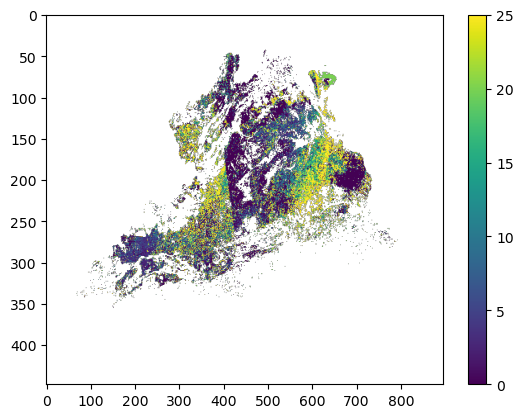

In [35]:
plt.imshow(calibrated.calibration.values[:,:,0], cmap="viridis", aspect="auto", vmin=0, vmax=25)
plt.colorbar()
plt.show()

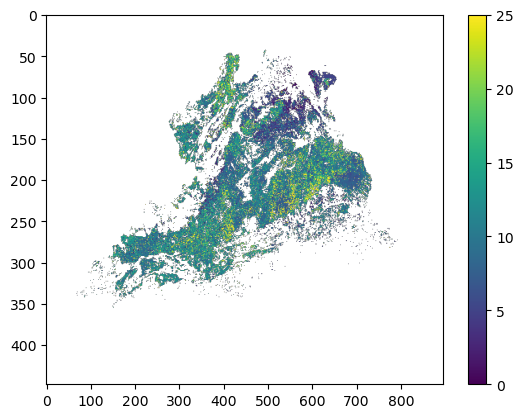

In [36]:
plt.imshow(calibrated.calibration.values[:,:,1], cmap="viridis", aspect="auto", vmin=0, vmax=25)
plt.colorbar()
plt.show()

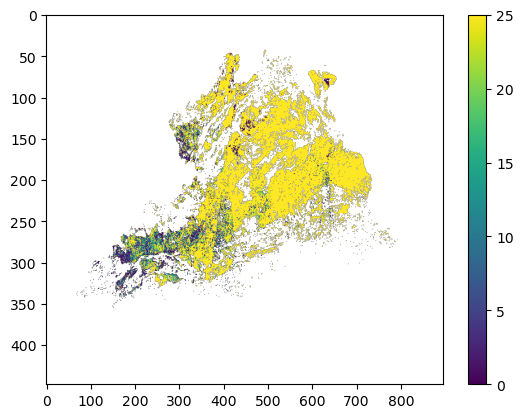

In [37]:
plt.imshow(calibrated.calibration.values[:,:,2], cmap="viridis", aspect="auto", vmin=0, vmax=25)
plt.colorbar()
plt.show()

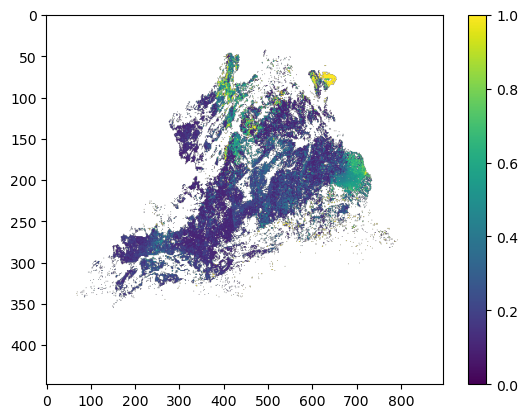

In [38]:
plt.imshow(calibrated.calibration.values[:,:,3], cmap="viridis", aspect="auto", vmin=0, vmax=1)
plt.colorbar()
plt.show()

In [39]:
arr_reshaped = calibrated.calibration.values.reshape(-1, 4)

In [40]:
unique_param_sets = np.unique(arr_reshaped, axis=0)

print(f"Number of unique parameter sets: {len(unique_param_sets)}")
print(unique_param_sets)

Number of unique parameter sets: 400576
[[0.00000000e+00 1.00000000e-02 1.00000000e+00 1.90027855e-01]
 [0.00000000e+00 1.00000000e-02 1.00000000e+00 7.20495435e-01]
 [0.00000000e+00 1.00000000e-02 2.84369538e+01 2.80188537e-01]
 ...
 [           nan            nan            nan            nan]
 [           nan            nan            nan            nan]
 [           nan            nan            nan            nan]]


In [41]:
unique_param_sets_no_nan = unique_param_sets[~np.isnan(unique_param_sets).any(axis=1)]
print(f"Unique parameter sets without NaNs: {len(unique_param_sets_no_nan)}")
print(unique_param_sets_no_nan)

Unique parameter sets without NaNs: 55541
[[0.00000000e+00 1.00000000e-02 1.00000000e+00 1.90027855e-01]
 [0.00000000e+00 1.00000000e-02 1.00000000e+00 7.20495435e-01]
 [0.00000000e+00 1.00000000e-02 2.84369538e+01 2.80188537e-01]
 ...
 [2.00000000e+02 5.00000000e+01 3.84921501e+01 1.00000000e-01]
 [2.00000000e+02 5.00000000e+01 1.72111886e+02 1.00000000e-01]
 [2.00000000e+02 5.00000000e+01 2.48993369e+02 3.30751162e-01]]
